# Gaussian-Mixture Model(GMM)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
# Check current working directory

print(os.getcwd())

c:\Users\Greesha Vaishnavi\Desktop\dsprojects\E_Commerce_Customer_Segmentation\research


In [3]:
# Load transformed data

rfm = pd.read_csv("../artifacts/data_transformation/customer_rfm.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [4]:
# Check data shape

print("Shape:", rfm.shape)

Shape: (4338, 4)


In [5]:
# Check columns

print("Columns:", rfm.columns.tolist())

Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [6]:
# Check missing values

print(rfm.isnull().sum())

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


In [7]:
# Separate customer ID and features

customer_ids = rfm["CustomerID"]

X = rfm[["Recency", "Frequency", "Monetary"]]

print("Customer IDs shape:", customer_ids.shape)
print("Features shape:", X.shape)

Customer IDs shape: (4338,)
Features shape: (4338, 3)


# Data Preprocessing

In [8]:
# Check skewness

print(X.skew())

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [9]:
# Apply log transformation

X_log = np.log1p(X)

X_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [10]:
#Check skewness after log transformation

print(X_log.skew())

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64


In [11]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [12]:
# Scale features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_log.columns,
    index=X_log.index
)

X_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [13]:
# Check scaled features

print("Mean:")
print(X_scaled.mean())

print("\nStandard Deviation:")
print(X_scaled.std())

Mean:
Recency     -8.025955e-17
Frequency   -8.189750e-18
Monetary    -3.734526e-16
dtype: float64

Standard Deviation:
Recency      1.000115
Frequency    1.000115
Monetary     1.000115
dtype: float64


# Baseline GMM

In [14]:
# Create baseline GMM

baseline_gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

In [15]:
# Fit baseline GMM

baseline_gmm.fit(X_scaled)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [16]:
# Get baseline cluster labels

baseline_labels = baseline_gmm.predict(
    X_scaled
)

In [17]:
# Add baseline cluster labels

rfm["Baseline_Cluster"] = baseline_labels

In [18]:
# Check baseline cluster distribution

rfm["Baseline_Cluster"].value_counts().sort_index()

Baseline_Cluster
0     835
1     867
2    1143
3    1493
Name: count, dtype: int64

In [19]:
# Calculate baseline Silhouette Score

baseline_silhouette = silhouette_score(
    X_scaled,
    baseline_labels
)

In [20]:
# Calculate baseline Davies-Bouldin Index

baseline_davies_bouldin = davies_bouldin_score(
    X_scaled,
    baseline_labels
)

In [21]:
# Calculate baseline Calinski-Harabasz Score

baseline_calinski = calinski_harabasz_score(
    X_scaled,
    baseline_labels
)

In [22]:
# Calculate AIC

baseline_aic = baseline_gmm.aic(
    X_scaled
)

In [23]:
# Calculate BIC

baseline_bic = baseline_gmm.bic(
    X_scaled
)

In [24]:
# Print baseline evaluation results

print("Baseline Gaussian Mixture Model Evaluation")

print(
    f"Silhouette Score: "
    f"{baseline_silhouette:.4f}"
)

print(
    f"Davies-Bouldin Index: "
    f"{baseline_davies_bouldin:.4f}"
)

print(
    f"Calinski-Harabasz Score: "
    f"{baseline_calinski:.2f}"
)

print(
    f"AIC: "
    f"{baseline_aic:.2f}"
)

print(
    f"BIC: "
    f"{baseline_bic:.2f}"
)

print(
    f"Number of Components: "
    f"{baseline_gmm.n_components}"
)

Baseline Gaussian Mixture Model Evaluation
Silhouette Score: 0.1761
Davies-Bouldin Index: 1.7048
Calinski-Harabasz Score: 2170.60
AIC: 3603.04
BIC: 3851.67
Number of Components: 4


# Hyperparameter Experiment

In [25]:
# Run GMM hyperparameter experiments

experiment_results = []

n_components_values = range(2, 11)
covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

for n_components in n_components_values:

    for covariance_type in covariance_types:

        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=42,
            n_init=10
        )

        model.fit(X_scaled)

        labels = model.predict(X_scaled)

        silhouette = silhouette_score(
            X_scaled,
            labels
        )

        davies_bouldin = davies_bouldin_score(
            X_scaled,
            labels
        )

        calinski_harabasz = calinski_harabasz_score(
            X_scaled,
            labels
        )

        aic = model.aic(X_scaled)

        bic = model.bic(X_scaled)

        experiment_results.append({
            "n_components": n_components,
            "covariance_type": covariance_type,
            "silhouette_score": silhouette,
            "davies_bouldin_score": davies_bouldin,
            "calinski_harabasz_score": calinski_harabasz,
            "aic": aic,
            "bic": bic
        })

In [26]:
# Create experiment results DataFrame

experiment_results_df = pd.DataFrame(
    experiment_results
)

experiment_results_df

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
0,2,full,0.285491,1.067031,2288.485389,13335.093648,13456.221853
1,2,tied,0.411639,0.840526,2580.702807,29949.578462,30032.455655
2,2,diag,0.416669,0.917827,4159.210668,31683.743943,31766.621136
3,2,spherical,0.430724,0.902321,4300.759412,32563.449542,32620.826060
4,3,full,0.252099,1.246761,2749.903916,12439.531590,12624.411482
5,3,tied,0.328400,1.004507,2490.001989,29588.514217,29696.892084
6,3,diag,0.266618,1.239199,2965.805694,13725.638633,13853.142006
7,3,spherical,0.337050,1.012751,3515.484484,31388.552168,31477.804530
8,4,full,0.172846,1.723719,2146.562450,3593.278429,3841.910008
9,4,tied,0.308307,1.000722,2338.331972,29390.171988,29524.050530


In [27]:
# Sort by Silhouette Score

experiment_results_df.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
3,2,spherical,0.430724,0.902321,4300.759412,32563.449542,32620.826060
2,2,diag,0.416669,0.917827,4159.210668,31683.743943,31766.621136
1,2,tied,0.411639,0.840526,2580.702807,29949.578462,30032.455655
7,3,spherical,0.337050,1.012751,3515.484484,31388.552168,31477.804530
11,4,spherical,0.329677,1.000371,3248.769192,30792.353789,30913.481995
5,3,tied,0.328400,1.004507,2490.001989,29588.514217,29696.892084
15,5,spherical,0.309419,0.995595,3023.563571,30056.388937,30209.392986
9,4,tied,0.308307,1.000722,2338.331972,29390.171988,29524.050530
19,6,spherical,0.306211,1.024631,2981.411365,29716.025038,29900.904930
23,7,spherical,0.292303,1.031029,2803.522087,29389.883195,29606.638931


In [28]:
# Sort by AIC

experiment_results_df.sort_values(
    by="aic",
    ascending=True
).head(10)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
32,10,full,0.101040,2.565677,1138.180657,-8353.368932,-7722.227231
34,10,diag,0.026234,2.495189,1081.915232,-7770.032750,-7330.146111
30,9,diag,0.038273,2.705225,1158.324572,-7743.954342,-7348.693883
28,9,full,0.121369,2.359350,1260.239417,-6126.388773,-5558.998759
24,8,full,0.123575,2.406263,1355.454648,-6082.827160,-5579.188833
26,8,diag,0.126325,2.390610,1428.326074,-5952.403187,-5601.768909
20,7,full,0.107084,2.532341,1322.381204,-5488.034386,-5048.147746
22,7,diag,0.112697,2.566661,1367.183654,-5350.165504,-5044.157407
16,6,full,0.122494,2.180516,1496.655621,-1730.001108,-1353.866155
18,6,diag,0.129336,2.267562,1601.438523,-1583.481412,-1322.099495


In [29]:
# Sort by BIC

experiment_results_df.sort_values(
    by="bic",
    ascending=True
).head(10)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
32,10,full,0.101040,2.565677,1138.180657,-8353.368932,-7722.227231
30,9,diag,0.038273,2.705225,1158.324572,-7743.954342,-7348.693883
34,10,diag,0.026234,2.495189,1081.915232,-7770.032750,-7330.146111
26,8,diag,0.126325,2.390610,1428.326074,-5952.403187,-5601.768909
24,8,full,0.123575,2.406263,1355.454648,-6082.827160,-5579.188833
28,9,full,0.121369,2.359350,1260.239417,-6126.388773,-5558.998759
20,7,full,0.107084,2.532341,1322.381204,-5488.034386,-5048.147746
22,7,diag,0.112697,2.566661,1367.183654,-5350.165504,-5044.157407
16,6,full,0.122494,2.180516,1496.655621,-1730.001108,-1353.866155
18,6,diag,0.129336,2.267562,1601.438523,-1583.481412,-1322.099495


In [30]:
# Sort by Davies-Bouldin Index

experiment_results_df.sort_values(
    by="davies_bouldin_score",
    ascending=True
).head(10)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
1,2,tied,0.411639,0.840526,2580.702807,29949.578462,30032.455655
3,2,spherical,0.430724,0.902321,4300.759412,32563.449542,32620.826060
2,2,diag,0.416669,0.917827,4159.210668,31683.743943,31766.621136
27,8,spherical,0.241222,0.963828,2450.153238,28903.030486,29151.662065
31,9,spherical,0.240662,0.975208,2429.571616,28671.866820,28952.374242
15,5,spherical,0.309419,0.995595,3023.563571,30056.388937,30209.392986
11,4,spherical,0.329677,1.000371,3248.769192,30792.353789,30913.481995
9,4,tied,0.308307,1.000722,2338.331972,29390.171988,29524.050530
5,3,tied,0.328400,1.004507,2490.001989,29588.514217,29696.892084
7,3,spherical,0.337050,1.012751,3515.484484,31388.552168,31477.804530


In [31]:
# Sort by Calinski-Harabasz Score

experiment_results_df.sort_values(
    by="calinski_harabasz_score",
    ascending=False
).head(10)

,n_components,covariance_type,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
3,2,spherical,0.430724,0.902321,4300.759412,32563.449542,32620.826060
2,2,diag,0.416669,0.917827,4159.210668,31683.743943,31766.621136
7,3,spherical,0.337050,1.012751,3515.484484,31388.552168,31477.804530
11,4,spherical,0.329677,1.000371,3248.769192,30792.353789,30913.481995
15,5,spherical,0.309419,0.995595,3023.563571,30056.388937,30209.392986
19,6,spherical,0.306211,1.024631,2981.411365,29716.025038,29900.904930
6,3,diag,0.266618,1.239199,2965.805694,13725.638633,13853.142006
23,7,spherical,0.292303,1.031029,2803.522087,29389.883195,29606.638931
4,3,full,0.252099,1.246761,2749.903916,12439.531590,12624.411482
17,6,tied,0.266989,1.098165,2609.728464,29300.095085,29484.974977


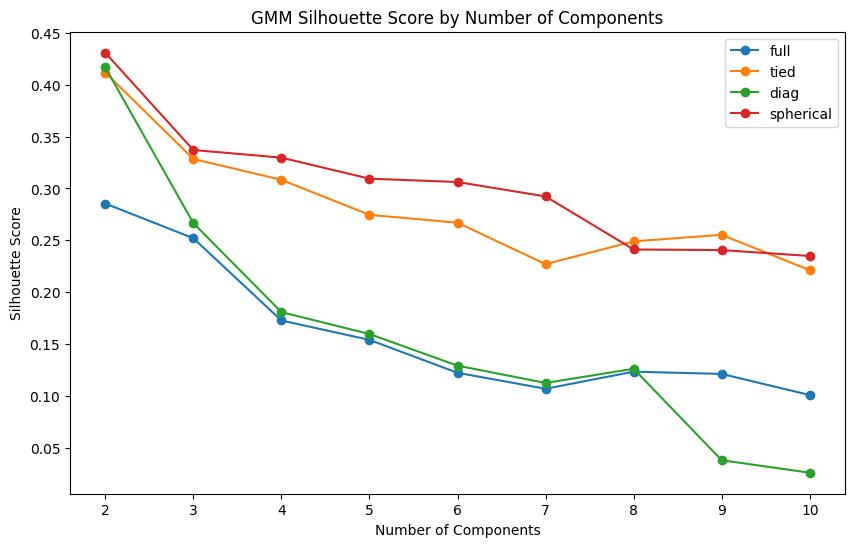

In [32]:
# Plot Silhouette Score

plt.figure(figsize=(10, 6))

for covariance_type in covariance_types:

    subset = experiment_results_df[
        experiment_results_df["covariance_type"] == covariance_type
    ]

    plt.plot(
        subset["n_components"],
        subset["silhouette_score"],
        marker="o",
        label=covariance_type
    )

plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("GMM Silhouette Score by Number of Components")
plt.legend()
plt.show()

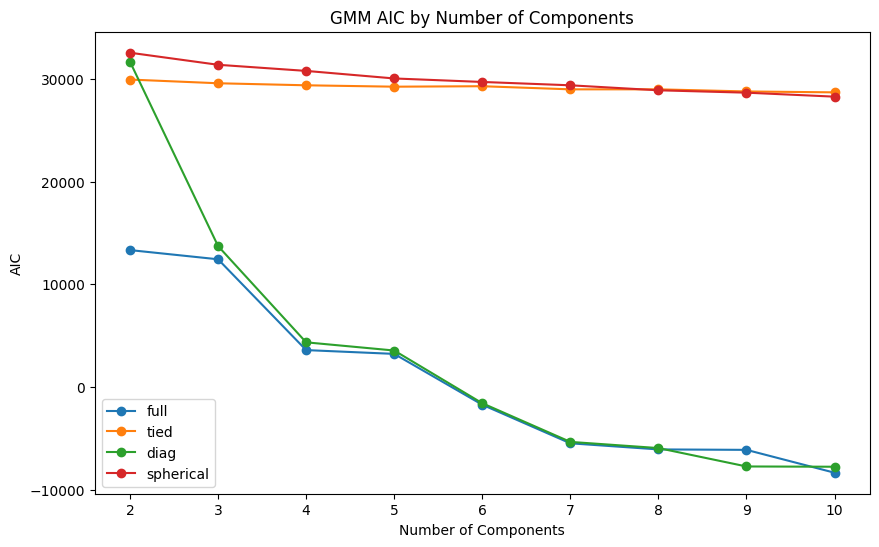

In [33]:
# Plot AIC

plt.figure(figsize=(10, 6))

for covariance_type in covariance_types:

    subset = experiment_results_df[
        experiment_results_df["covariance_type"] == covariance_type
    ]

    plt.plot(
        subset["n_components"],
        subset["aic"],
        marker="o",
        label=covariance_type
    )

plt.xlabel("Number of Components")
plt.ylabel("AIC")
plt.title("GMM AIC by Number of Components")
plt.legend()
plt.show()

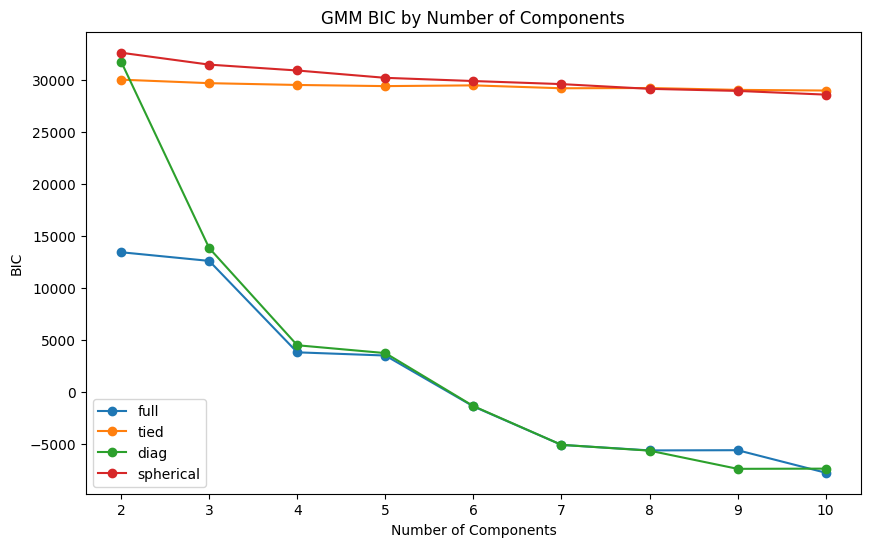

In [34]:
# Plot BIC

plt.figure(figsize=(10, 6))

for covariance_type in covariance_types:

    subset = experiment_results_df[
        experiment_results_df["covariance_type"] == covariance_type
    ]

    plt.plot(
        subset["n_components"],
        subset["bic"],
        marker="o",
        label=covariance_type
    )

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM BIC by Number of Components")
plt.legend()
plt.show()

# Hyperparameter Tuning

In [35]:
# Define GMM tuning parameters

tuning_n_components = range(2, 11)

tuning_covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

tuning_n_init = [
    10,
    20
]

tuning_reg_covar = [
    1e-6,
    1e-5,
    1e-4
]

In [36]:
# Run GMM hyperparameter tuning

tuning_results = []

for n_components in tuning_n_components:

    for covariance_type in tuning_covariance_types:

        for n_init in tuning_n_init:

            for reg_covar in tuning_reg_covar:

                model = GaussianMixture(
                    n_components=n_components,
                    covariance_type=covariance_type,
                    n_init=n_init,
                    reg_covar=reg_covar,
                    random_state=42
                )

                model.fit(X_scaled)

                labels = model.predict(X_scaled)

                silhouette = silhouette_score(
                    X_scaled,
                    labels
                )

                davies_bouldin = davies_bouldin_score(
                    X_scaled,
                    labels
                )

                calinski_harabasz = calinski_harabasz_score(
                    X_scaled,
                    labels
                )

                aic = model.aic(X_scaled)

                bic = model.bic(X_scaled)

                tuning_results.append({
                    "n_components": n_components,
                    "covariance_type": covariance_type,
                    "n_init": n_init,
                    "reg_covar": reg_covar,
                    "silhouette_score": silhouette,
                    "davies_bouldin_score": davies_bouldin,
                    "calinski_harabasz_score": calinski_harabasz,
                    "aic": aic,
                    "bic": bic
                })

In [37]:
# Create tuning results DataFrame

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df.shape

(216, 9)

In [38]:
# Sort tuning results by Silhouette Score

tuning_results_df.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
22,2,spherical,20,0.000010,0.430724,0.902321,4300.759412,32563.451887,32620.828406
23,2,spherical,20,0.000100,0.430724,0.902321,4300.759412,32563.475629,32620.852147
19,2,spherical,10,0.000010,0.430724,0.902321,4300.759412,32563.451887,32620.828406
18,2,spherical,10,0.000001,0.430724,0.902321,4300.759412,32563.449542,32620.826060
21,2,spherical,20,0.000001,0.430724,0.902321,4300.759412,32563.449542,32620.826060
20,2,spherical,10,0.000100,0.430724,0.902321,4300.759412,32563.475629,32620.852147
17,2,diag,20,0.000100,0.416735,0.917761,4159.858679,31683.912582,31766.789775
14,2,diag,10,0.000100,0.416735,0.917761,4159.858679,31683.912582,31766.789775
13,2,diag,10,0.000010,0.416669,0.917827,4159.210668,31683.759211,31766.636404
12,2,diag,10,0.000001,0.416669,0.917827,4159.210668,31683.743943,31766.621136


In [39]:
# Sort tuning results by BIC

tuning_results_df.sort_values(
    by="bic",
    ascending=True
).head(10)

,n_components,covariance_type,n_init,reg_covar,silhouette_score,davies_bouldin_score,calinski_harabasz_score,aic,bic
192,10,full,10,0.000001,0.101040,2.565677,1138.180657,-8353.368932,-7722.227231
195,10,full,20,0.000001,0.101040,2.565677,1138.180657,-8353.368932,-7722.227231
207,10,diag,20,0.000001,0.065008,2.738079,1092.953006,-7803.229423,-7363.342783
183,9,diag,20,0.000001,0.038273,2.705225,1158.324572,-7743.954342,-7348.693883
180,9,diag,10,0.000001,0.038273,2.705225,1158.324572,-7743.954342,-7348.693883
204,10,diag,10,0.000001,0.026234,2.495189,1081.915232,-7770.032750,-7330.146111
159,8,diag,20,0.000001,0.097933,2.992100,1179.100110,-7628.903560,-7278.269282
147,8,full,20,0.000001,0.091523,2.982625,1135.060369,-7748.156484,-7244.518157
156,8,diag,10,0.000001,0.126325,2.390610,1428.326074,-5952.403187,-5601.768909
144,8,full,10,0.000001,0.123575,2.406263,1355.454648,-6082.827160,-5579.188833


In [40]:
# Compare best configurations from each metric

best_silhouette = tuning_results_df.loc[
    tuning_results_df["silhouette_score"].idxmax()
]

best_davies_bouldin = tuning_results_df.loc[
    tuning_results_df["davies_bouldin_score"].idxmin()
]

best_calinski = tuning_results_df.loc[
    tuning_results_df["calinski_harabasz_score"].idxmax()
]

best_aic = tuning_results_df.loc[
    tuning_results_df["aic"].idxmin()
]

best_bic = tuning_results_df.loc[
    tuning_results_df["bic"].idxmin()
]

In [41]:
# Display best configuration from each metric

metric_comparison = pd.DataFrame({
    "Metric": [
        "Silhouette",
        "Davies-Bouldin",
        "Calinski-Harabasz",
        "AIC",
        "BIC"
    ],
    "Best Components": [
        best_silhouette["n_components"],
        best_davies_bouldin["n_components"],
        best_calinski["n_components"],
        best_aic["n_components"],
        best_bic["n_components"]
    ],
    "Covariance Type": [
        best_silhouette["covariance_type"],
        best_davies_bouldin["covariance_type"],
        best_calinski["covariance_type"],
        best_aic["covariance_type"],
        best_bic["covariance_type"]
    ],
    "Silhouette": [
        best_silhouette["silhouette_score"],
        best_davies_bouldin["silhouette_score"],
        best_calinski["silhouette_score"],
        best_aic["silhouette_score"],
        best_bic["silhouette_score"]
    ],
    "AIC": [
        best_silhouette["aic"],
        best_davies_bouldin["aic"],
        best_calinski["aic"],
        best_aic["aic"],
        best_bic["aic"]
    ],
    "BIC": [
        best_silhouette["bic"],
        best_davies_bouldin["bic"],
        best_calinski["bic"],
        best_aic["bic"],
        best_bic["bic"]
    ]
})

metric_comparison

,Metric,Best Components,Covariance Type,Silhouette,AIC,BIC
0,Silhouette,2,spherical,0.430724,32563.449542,32620.826060
1,Davies-Bouldin,2,tied,0.411639,29949.578462,30032.455655
2,Calinski-Harabasz,2,spherical,0.430724,32563.449542,32620.826060
3,AIC,10,full,0.101040,-8353.368932,-7722.227231
4,BIC,10,full,0.101040,-8353.368932,-7722.227231


In [42]:
# Create tuned GMM

tuned_gmm = GaussianMixture(
    n_components=2,
    covariance_type="spherical",
    n_init=20,
    reg_covar=1e-6,
    random_state=42
)

In [43]:
# Fit tuned GMM

tuned_gmm.fit(X_scaled)

,n_components,2
,covariance_type,'spherical'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,20
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [44]:
# Generate tuned cluster labels

tuned_labels = tuned_gmm.predict(X_scaled)

In [45]:
# Calculate tuned evaluation metrics

tuned_silhouette = silhouette_score(
    X_scaled,
    tuned_labels
)

tuned_davies_bouldin = davies_bouldin_score(
    X_scaled,
    tuned_labels
)

tuned_calinski = calinski_harabasz_score(
    X_scaled,
    tuned_labels
)

tuned_aic = tuned_gmm.aic(
    X_scaled
)

tuned_bic = tuned_gmm.bic(
    X_scaled
)

In [46]:
# Print tuned GMM evaluation

print("Tuned Gaussian Mixture Model Evaluation")

print(
    f"Silhouette Score: "
    f"{tuned_silhouette:.4f}"
)

print(
    f"Davies-Bouldin Index: "
    f"{tuned_davies_bouldin:.4f}"
)

print(
    f"Calinski-Harabasz Score: "
    f"{tuned_calinski:.2f}"
)

print(
    f"AIC: "
    f"{tuned_aic:.2f}"
)

print(
    f"BIC: "
    f"{tuned_bic:.2f}"
)

print(
    f"Number of Components: "
    f"{tuned_gmm.n_components}"
)

print(
    f"Covariance Type: "
    f"{tuned_gmm.covariance_type}"
)

Tuned Gaussian Mixture Model Evaluation
Silhouette Score: 0.4307
Davies-Bouldin Index: 0.9023
Calinski-Harabasz Score: 4300.76
AIC: 32563.45
BIC: 32620.83
Number of Components: 2
Covariance Type: spherical


# Baseline vs Tuned

In [47]:
# Compare baseline and tuned GMM

comparison = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score",
        "AIC",
        "BIC"
    ],
    "Baseline": [
        baseline_silhouette,
        baseline_davies_bouldin,
        baseline_calinski,
        baseline_aic,
        baseline_bic
    ],
    "Tuned": [
        tuned_silhouette,
        tuned_davies_bouldin,
        tuned_calinski,
        tuned_aic,
        tuned_bic
    ]
})

comparison

,Metric,Baseline,Tuned
0,Silhouette Score,0.176094,0.430724
1,Davies-Bouldin Index,1.704830,0.902321
2,Calinski-Harabasz Score,2170.602180,4300.759412
3,AIC,3603.037230,32563.449542
4,BIC,3851.668809,32620.826060


In [48]:
# Add tuned GMM clusters

rfm["GMM_Cluster"] = tuned_labels

In [49]:
# Check cluster distribution

rfm["GMM_Cluster"].value_counts().sort_index()

GMM_Cluster
0    2654
1    1684
Name: count, dtype: int64

In [50]:
# Check cluster percentage

rfm["GMM_Cluster"].value_counts(
    normalize=True
).sort_index() * 100

GMM_Cluster
0    61.180267
1    38.819733
Name: proportion, dtype: float64

In [51]:
# Create GMM cluster profile

cluster_profile = rfm.groupby("GMM_Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    CustomerCount=("CustomerID", "count")
).reset_index()

In [52]:
# Calculate customer percentage

cluster_profile["Percentage"] = (
    cluster_profile["CustomerCount"]
    / cluster_profile["CustomerCount"].sum()
    * 100
)

cluster_profile

,GMM_Cluster,Recency,Frequency,Monetary,CustomerCount,Percentage
0,0,134.574981,1.684250,490.883008,2654,61.180267
1,1,26.283254,8.350356,4503.803676,1684,38.819733


In [53]:
# Calculate cluster probabilities

cluster_probabilities = tuned_gmm.predict_proba(
    X_scaled
)

max_probability = cluster_probabilities.max(
    axis=1
)

rfm["Cluster_Probability"] = max_probability

In [54]:
# Check cluster probability

rfm["Cluster_Probability"].describe()

count    4338.000000
mean        0.934964
std         0.117155
min         0.500252
25%         0.933993
50%         0.993899
75%         0.999433
max         1.000000
Name: Cluster_Probability, dtype: float64

In [55]:
# Save GMM tuning results

tuning_results_df.to_csv(
    "../artifacts/data_transformation/gmm_tuning_results.csv",
    index=False
)

In [56]:
# Save customer GMM clusters

rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "GMM_Cluster",
        "Cluster_Probability"
    ]
].to_csv(
    "../artifacts/data_transformation/customer_clusters_gmm.csv",
    index=False
)

In [57]:
# Save GMM cluster profile

cluster_profile.to_csv(
    "../artifacts/data_transformation/gmm_cluster_profile.csv",
    index=False
)

# GMM Key Insights

- Gaussian Mixture Model was applied to the customer-level RFM data after log transformation and standardization.

- The baseline GMM used 4 Gaussian components with full covariance.

- The baseline model achieved a Silhouette Score of 0.1761, Davies-Bouldin Index of 1.7048, and Calinski-Harabasz Score of 2170.60.

- Hyperparameter experiments were performed by varying the number of components, covariance type, n_init, and regularization.

- The tuning results showed that the 2-component spherical covariance configuration provided the highest Silhouette Score of 0.4307 and a Calinski-Harabasz Score of 4300.76.

- The tuned model improved the Silhouette Score from 0.1761 to 0.4307 and reduced the Davies-Bouldin Index from 1.7048 to 0.9023, indicating better cluster separation.

- The Calinski-Harabasz Score also increased from 2170.60 to 4300.76 after tuning.

- The tuned model produced two customer segments:
  - Cluster 0: 2,654 customers (61.18%)
  - Cluster 1: 1,684 customers (38.82%)

- The two clusters are reasonably balanced, with both segments containing a substantial portion of customers.

- GMM also provides probability-based cluster membership, allowing customer assignments to be interpreted with a level of confidence rather than only using hard cluster labels.

- GMM is considered as one candidate model for the final customer segmentation solution. Its results will be compared with K-Means, Hierarchical Clustering, and DBSCAN before selecting the final model.